# Advection-Diffusion as a Non-Hermitian PDE Example

This notebook studies a small steady advection-diffusion problem

$$(\alpha I - D\Delta + v\partial_x)u=f$$

with Dirichlet boundary conditions. The centered first-derivative term makes the finite-difference operator non-Hermitian. That is useful pedagogically: direct Hermitian spectral calculus no longer applies to the raw operator.

A QSVT-compatible route is to work with singular values, here represented classically by the normal equations

$$B^T B u = B^T f.$$

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.design import design_inverse_polynomial
from qsvt.pde import dirichlet_laplacian_1d
from qsvt.spectral import apply_polynomial_to_hermitian, eigh_hermitian

np.set_printoptions(precision=4, suppress=True)

In [2]:
n_points = 8
diffusion = 0.015
velocity = 0.8
alpha = 1.0

x, negative_laplacian = dirichlet_laplacian_1d(n_points)
dx = x[1] - x[0]

gradient = np.zeros((n_points, n_points))
for i in range(n_points):
    if i > 0:
        gradient[i, i - 1] = -0.5 / dx
    if i < n_points - 1:
        gradient[i, i + 1] = 0.5 / dx

generator = -diffusion * negative_laplacian - velocity * gradient
B = alpha * np.eye(n_points) - generator
source = np.exp(-80.0 * (x - 0.3) ** 2)

non_normality = np.linalg.norm(B.T @ B - B @ B.T)
non_normality

np.float64(24.743080487279663)

## Normal-equation embedding

`B.T @ B` is Hermitian positive definite. Applying an inverse-like polynomial to this matrix is a small classical stand-in for a singular-value based QSVT treatment of the original non-Hermitian operator.

In [3]:
normal_matrix = B.T @ B
normal_source = B.T @ source
eigenvalues, _ = eigh_hermitian(normal_matrix)

lambda_min = eigenvalues[0]
lambda_max = eigenvalues[-1]
gamma = lambda_min / lambda_max
A = normal_matrix / lambda_max

degree = 35
coeffs = design_inverse_polynomial(gamma=gamma, degree=degree)

u_poly = apply_polynomial_to_hermitian(A, coeffs) @ normal_source
u_poly = u_poly / (gamma * lambda_max)
u_direct = np.linalg.solve(B, source)

relative_error = np.linalg.norm(u_poly - u_direct) / np.linalg.norm(u_direct)
gamma, 1.0 / gamma, relative_error

(np.float64(0.057449326656195406),
 np.float64(17.406644397844456),
 np.float64(0.22813071877482616))

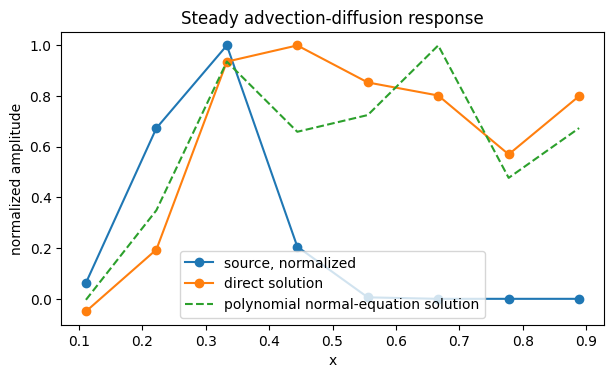

In [4]:
plt.figure(figsize=(7, 3.8))
plt.plot(x, source / np.max(source), "o-", label="source, normalized")
plt.plot(x, u_direct / np.max(np.abs(u_direct)), "o-", label="direct solution")
plt.plot(
    x,
    u_poly / np.max(np.abs(u_poly)),
    "--",
    label="polynomial normal-equation solution",
)
plt.xlabel("x")
plt.ylabel("normalized amplitude")
plt.title("Steady advection-diffusion response")
plt.legend()
plt.show()

## Validation

Compact checks for the expected numerical behavior.

In [5]:
assert non_normality > 0.0
assert np.isfinite(relative_error)
assert relative_error < 0.35
assert gamma > 0.0
assert u_poly.shape == u_direct.shape == source.shape

print(f"non_normality: {non_normality:.3e}")
print(f"normal_equation_condition_number: {1.0 / gamma:.3f}")
print(f"relative_error: {relative_error:.3e}")
print("validation: passed")

non_normality: 2.474e+01
normal_equation_condition_number: 17.407
relative_error: 2.281e-01
validation: passed
